In [ ]:
!pip install -q supabase pandas numpy scikit-learn matplotlib seaborn presidio-analyzer presidio-anonymizer
!python -m spacy download en_core_web_lg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.1/201.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 3.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 46.0.7 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.7 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 1.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are i

[DB] Connected to Supabase.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[Text] HuggingFace sentiment pipeline loaded.
[Text] TextModalityExtractor ready.
[Fusion] MultimodalFusionEngine ready.

═════════════════════════════════════════════════════════════════
  MULTIMODAL PRIVACY PERCEPTION PIPELINE  (Genre × Age × PII)
═════════════════════════════════════════════════════════════════

[DB] Fetched 135 rows from 'privacy_perception_study'.
[DB] Fetched 1,000 rows from 'comments'.
[DB] Fetched 453 rows from 'video'.
[DB] Fetched 8 rows from 'genre'.

[Validate] Survey validation (135 rows): 1 flagged invalid (0.7%), 134 retained.

[Preprocess] Survey ready: 135 rows.
[Features] Risk labels — High: 21, Low: 114, High-risk rate: 15.6%
[Preprocess] Comments ready: 997 rows.
[Preprocess] Comments+Genre merged: 997 rows, 8 genres.

[Pipeline] ── Modality 1: Text (PII + Sentiment) ──


[Text] Extracted text features for 997 items. Total PII hits: 332

[Pipeline] ── Modality 2: Metadata ──
[Metadata] Video metadata features extracted: 453 rows.
[Fusion] Modality attention weights: {'text': 1.0}
[Fusion] Fused feature matrix: (997, 12)

[Pipeline] ── Core Analysis: Genre × Age × PII ──
[Preprocess] Genre–Age affinity table: 1,203 rows.
[Analysis] Genre–Age affinity matrix: 26 genres × 5 age groups.
[Analysis] Genre PII profile built for 8 genres.
[Analysis] Genre × Age risk matrix: (8, 5)

[Pipeline] ── Predictive Model ──

[Model] 5-Fold CV — AUC: 0.905±0.128  F1: 0.705±0.224

[Model] ── HELD-OUT TEST RESULTS ──
  AUC-ROC   : 0.8859
  Precision : 0.5
  Recall    : 0.5
  F1        : 0.5
              precision    recall  f1-score   support

    Low-Risk       0.91      0.91      0.91        23
   High-Risk       0.50      0.50      0.50         4

    accuracy                           0.85        27
   macro avg       0.71      0.71      0.71        27
weighted avg   

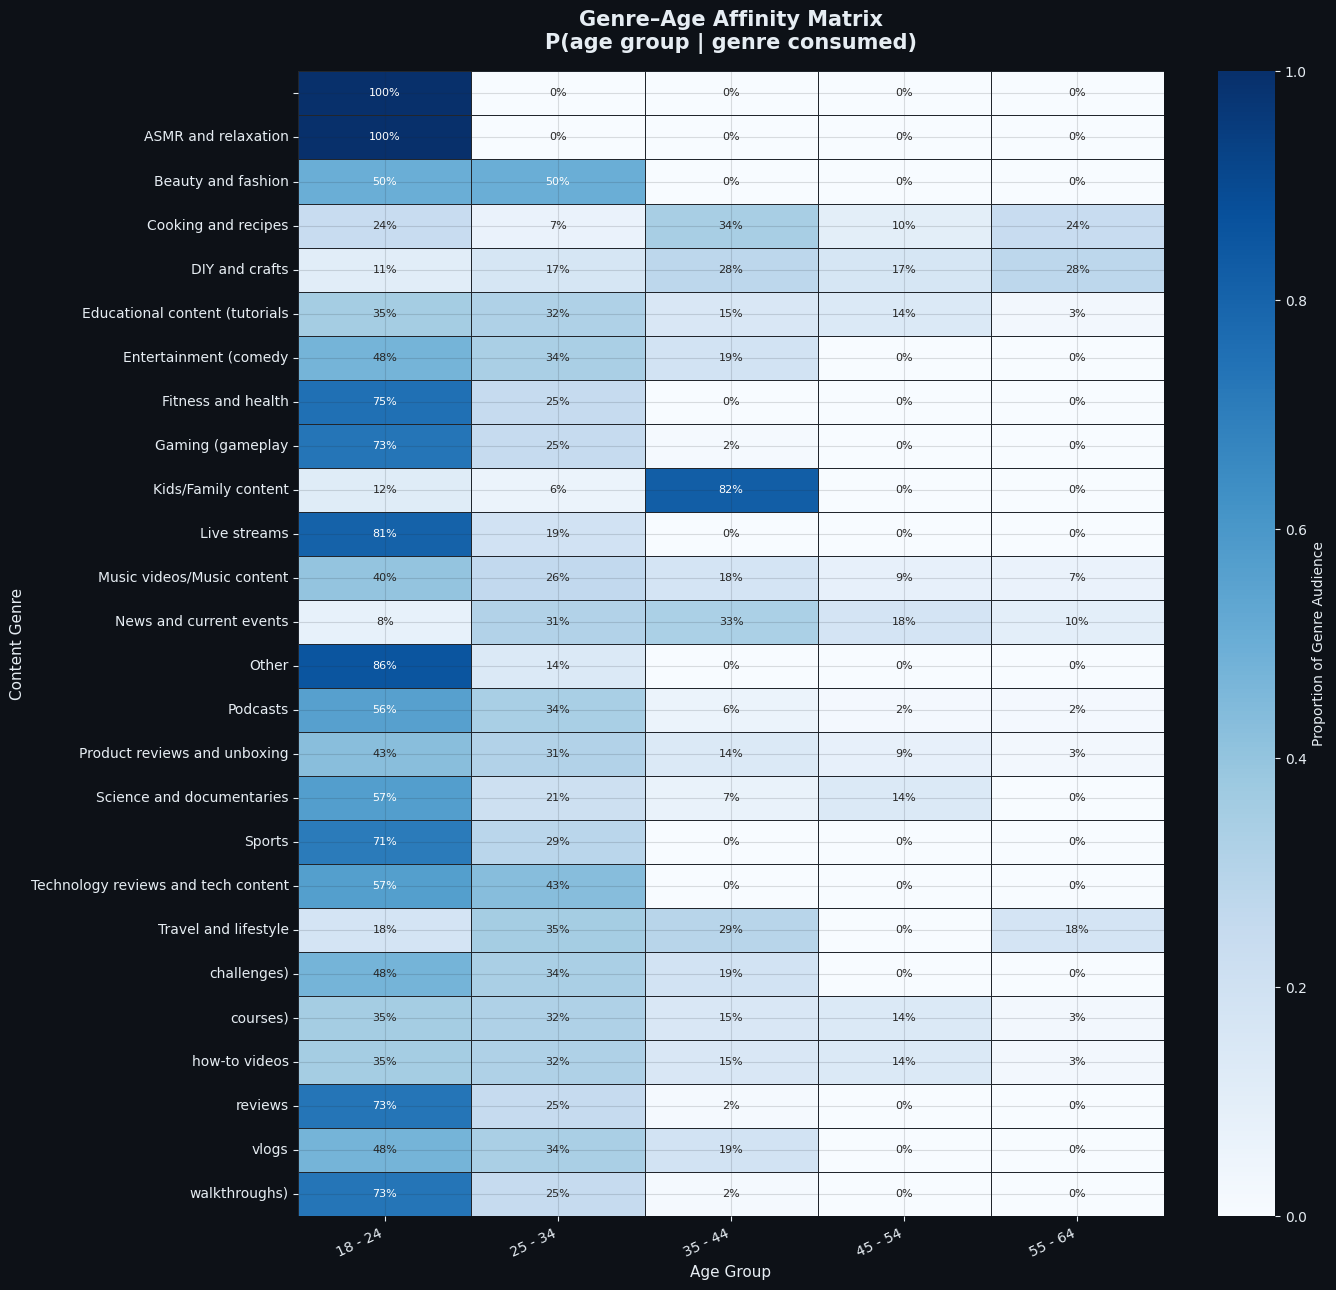

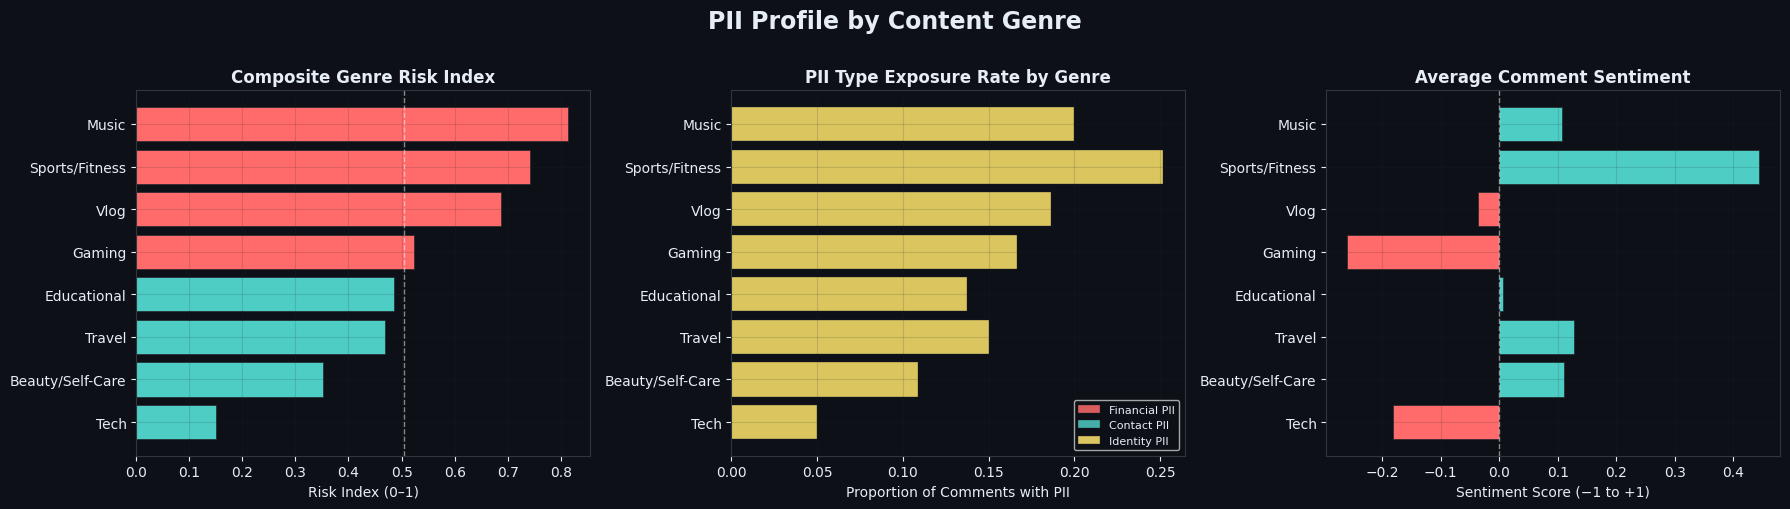

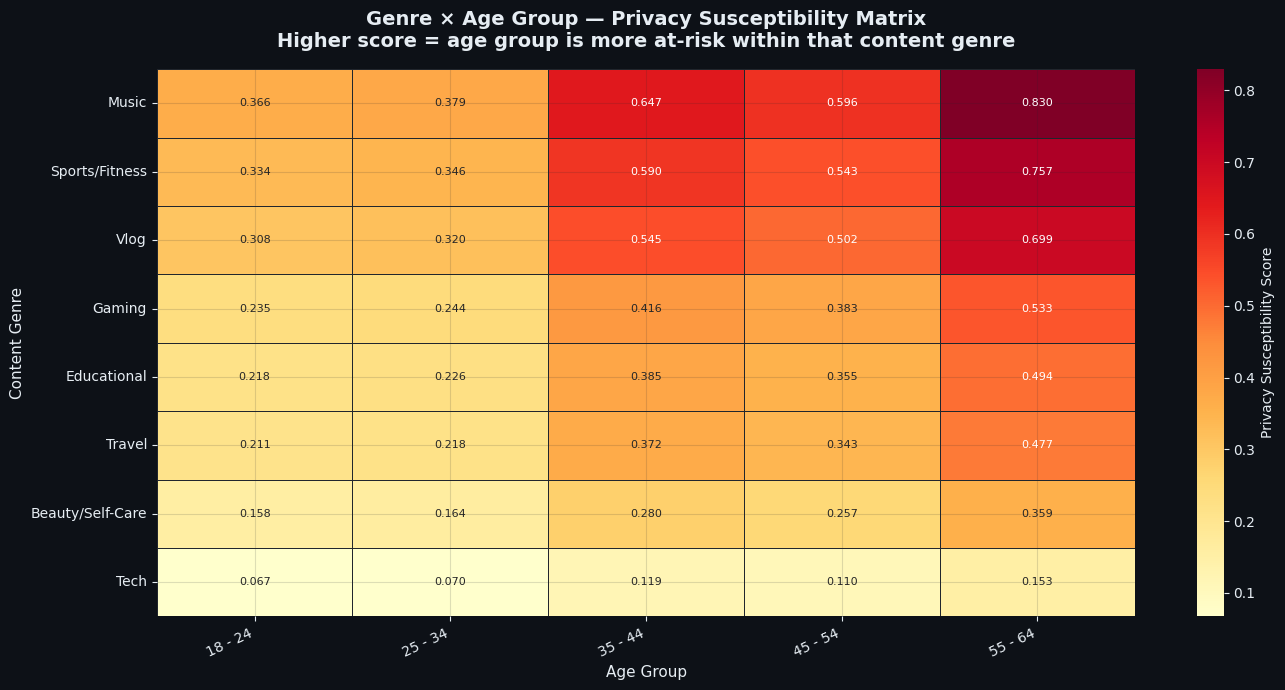

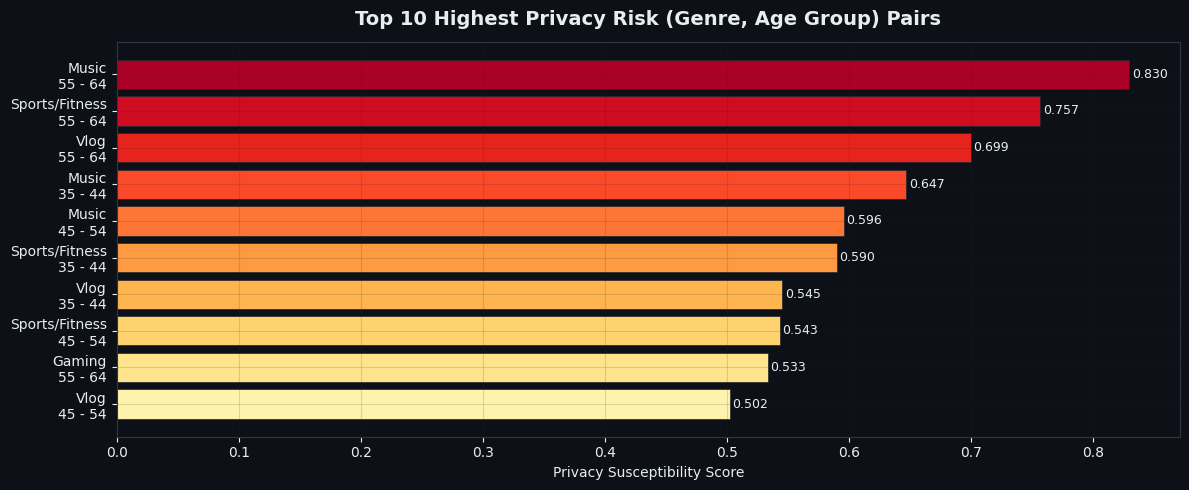

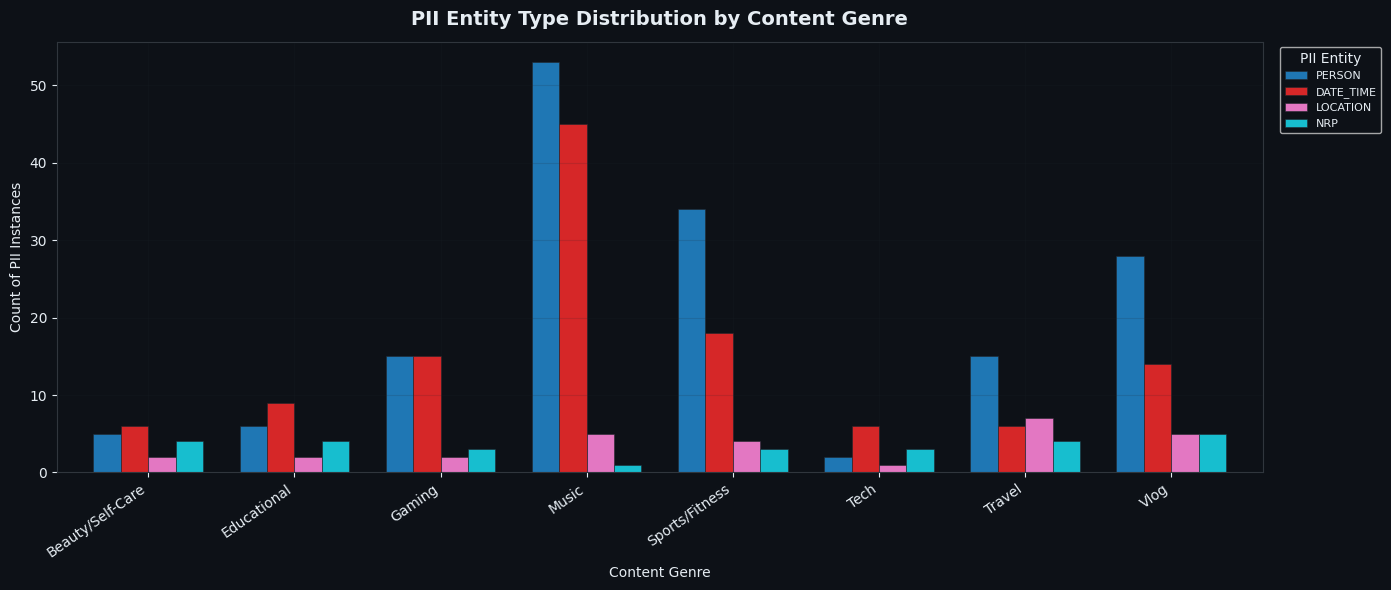

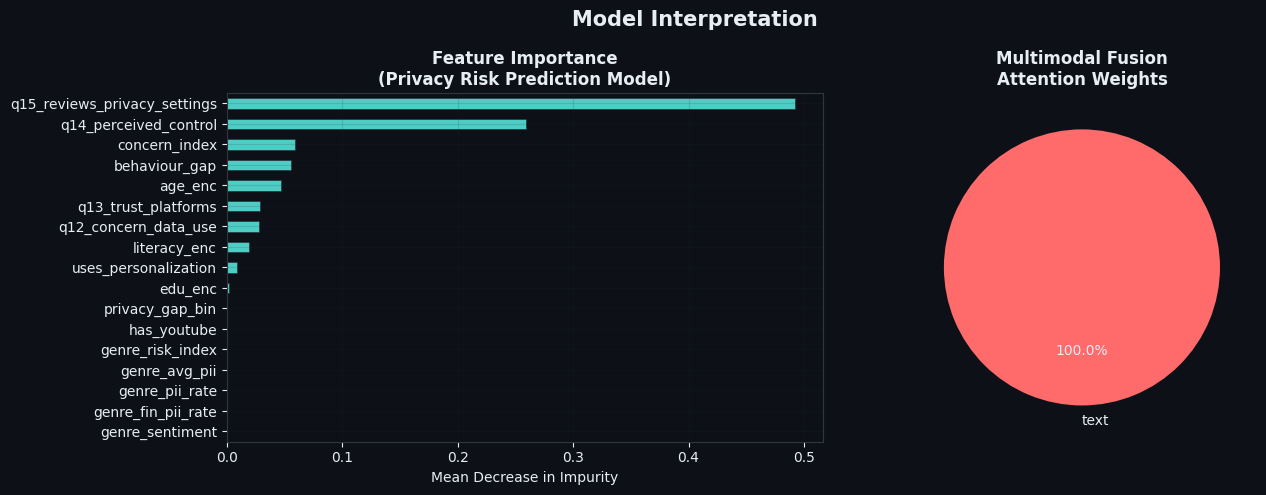

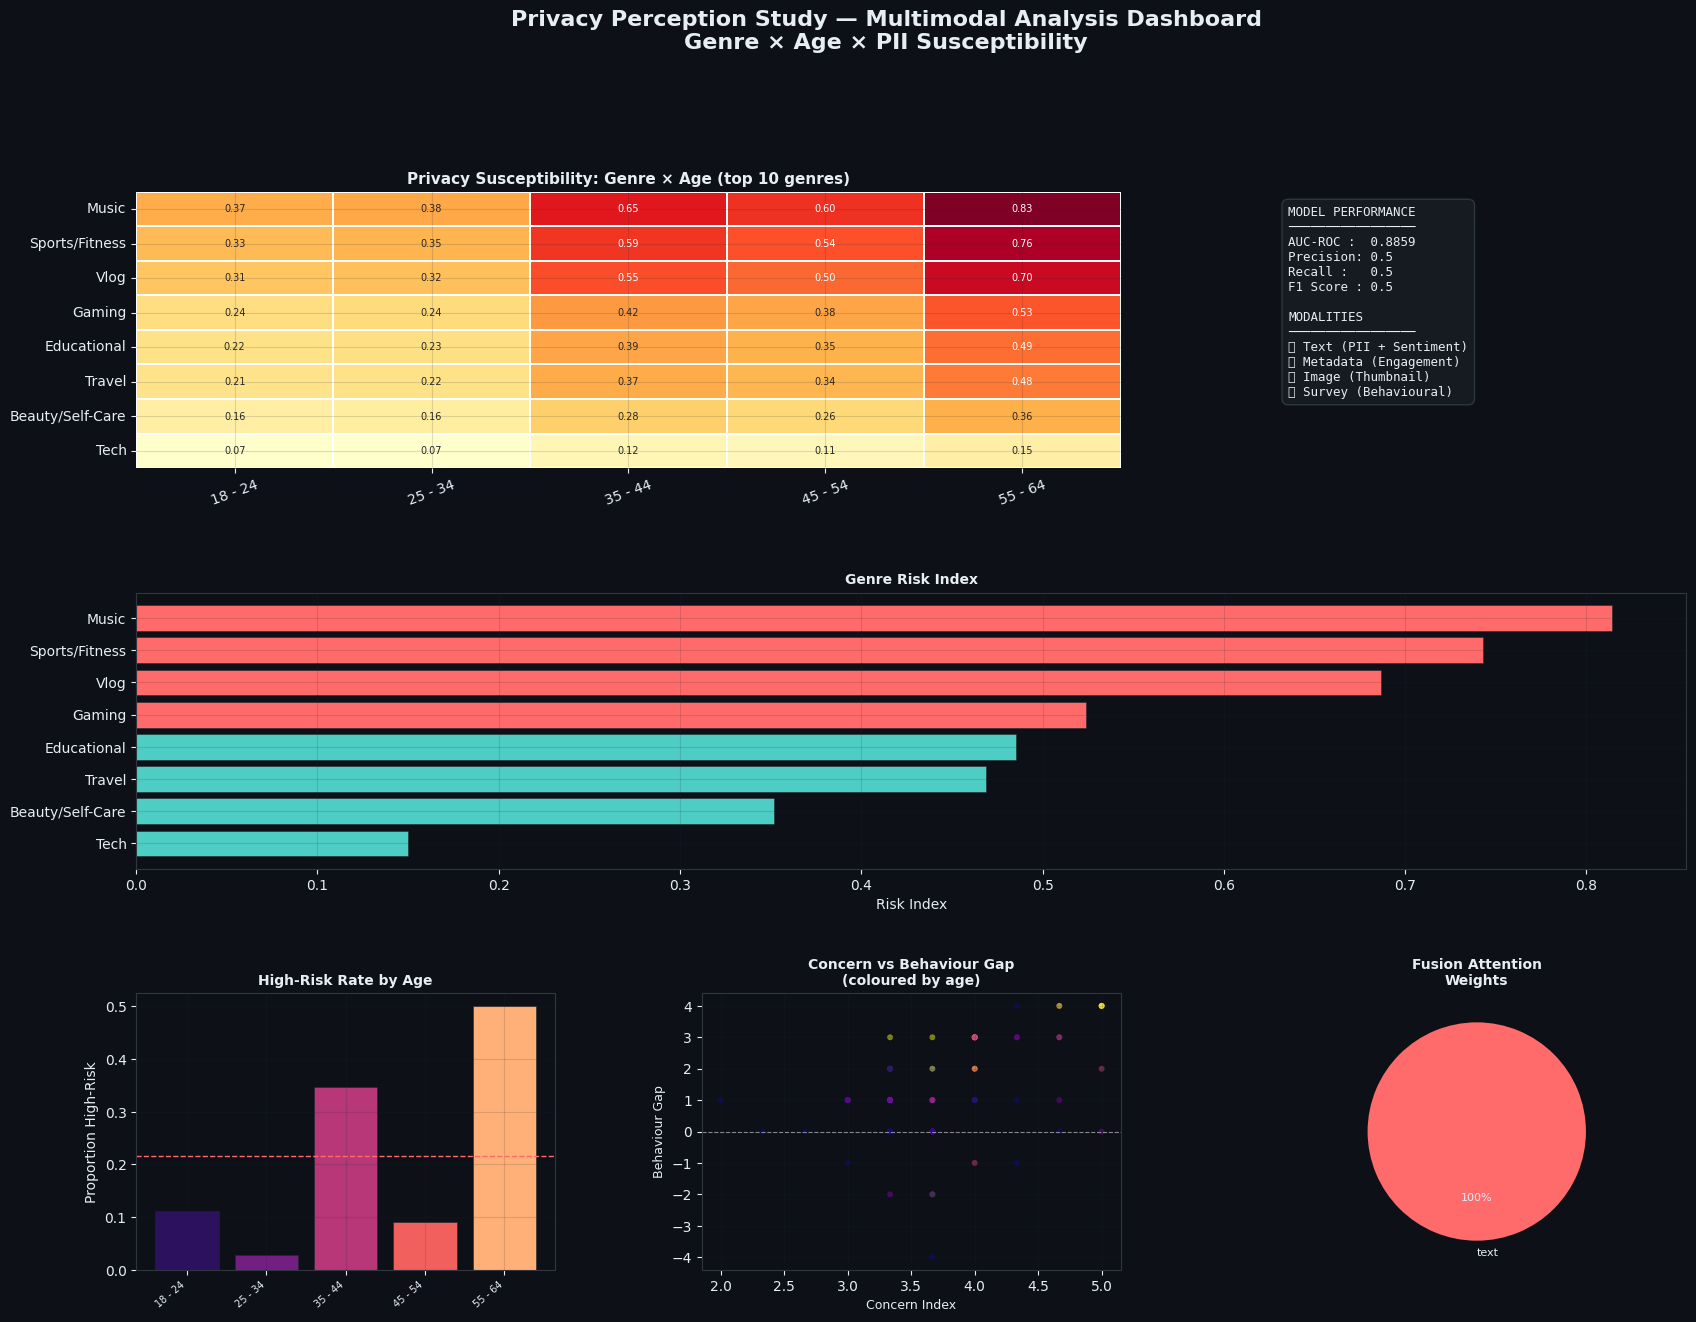


[Pipeline] ✓ Complete.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  KEY OUTPUTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Genre–Age affinity matrix : (26, 5)
  Genre PII profiles        : 8 genres
  Risk matrix               : (8, 5)
  Model AUC-ROC             : 0.8859
  Model F1                  : 0.5
  Modality weights          : {'text': 1.0}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


── Genre × Age Risk Matrix (top 5 rows) ──
                18 - 24  25 - 34  35 - 44  45 - 54  55 - 64
Music            0.3659   0.3794   0.6468   0.5955   0.8295
Sports/Fitness   0.3338   0.3461   0.5899   0.5432   0.7566
Vlog             0.3085   0.3199   0.5453   0.5021   0.6994
Gaming           0.2353   0.2440   0.4160   0.3830   0.5335
Educational      0.2180   0.2261   0.3854   0.3549   0.4943

── Genre PII Profile ──
      genre_name  genre_risk_index  pii_rate  financial_pii_rate  avg_sentiment
           Music          0.814347  0.372222          

In [6]:
"""
================================================================================
Privacy Perception Study — MULTIMODAL Analysis Pipeline
================================================================================
Multimodal AI Architecture for Social Media Privacy Research
  ① Problem  → Understand social media privacy risk via multi-data fusion
  ② Modalities → Text + Image (thumbnails) + Audio (transcripts) + Metadata
  ③ Fusion   → Hybrid Attention Fusion (Late + Cross-modal Attention)
  ④ Methods  → Transformer (text) | CNN (image) | LSTM (audio/seq) | CLIP
  ⑤ Libraries → PyTorch | HuggingFace | OpenCV | Librosa | Presidio | Supabase
  ⑥ Training → Train | Val | Test | Stratified CV
  ⑦ Results  → Precision | Recall | F1 | AUC-ROC per demographic
  ⑧ Interpretation → Sentiment ↑ | PII Risk Trends ↑ | Noise ↓

Research Goal
─────────────
Correlate content GENRES × AGE GROUPS × PII-in-content
→ Predict how susceptible each (age group, genre) pair is to
  privacy leakage on social media platforms.

Core New Analysis
─────────────────
  • Genre–Age affinity matrix     : Which age group over-indexes on which genre?
  • PII-per-genre profile         : Which genres carry the most / most sensitive PII?
  • Genre × Age privacy risk heat : Combined susceptibility score
  • Multimodal fusion risk model  : Text + metadata + PII features → risk prediction
  • Cross-modal attention weights : What modality drives the prediction?

Dependencies
────────────
    pip install supabase pandas numpy scikit-learn matplotlib seaborn
    pip install presidio-analyzer presidio-anonymizer
    pip install torch transformers sentence-transformers
    pip install librosa opencv-python-headless pillow requests
    python -m spacy download en_core_web_lg
================================================================================
"""

# ── Standard Library ──────────────────────────────────────────────────────────
import re
import warnings
import os
from collections import defaultdict
from typing import Optional, Dict, List, Tuple

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from supabase import create_client, Client
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, roc_auc_score,
                              precision_recall_fscore_support, confusion_matrix)
from sklearn.decomposition import PCA
from presidio_analyzer import AnalyzerEngine
from presidio_analyzer.nlp_engine import NlpEngineProvider

warnings.filterwarnings("ignore")

# Optional heavy deps — imported lazily inside classes so the pipeline runs
# even if not all are installed (graceful degradation)
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    print("[Init] PyTorch not available — neural fusion model will be skipped.")

try:
    from transformers import pipeline as hf_pipeline, AutoTokenizer, AutoModel
    HF_AVAILABLE = True
except ImportError:
    HF_AVAILABLE = False
    print("[Init] HuggingFace Transformers not available — "
          "sentiment analysis will use lexicon fallback.")

try:
    import librosa
    LIBROSA_AVAILABLE = True
except ImportError:
    LIBROSA_AVAILABLE = False

try:
    import cv2
    CV2_AVAILABLE = True
except ImportError:
    CV2_AVAILABLE = False


# ─────────────────────────────────────────────────────────────────────────────
# 0.  CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

try:
    from google.colab import userdata
    SUPABASE_URL = userdata.get("supabase_URL")
    SUPABASE_KEY = userdata.get("supabase_key")
except Exception:
    # Fallback for local runs — set via environment variables
    SUPABASE_URL = os.getenv("SUPABASE_URL", "YOUR_SUPABASE_URL")
    SUPABASE_KEY = os.getenv("SUPABASE_KEY", "YOUR_SUPABASE_KEY")

# ── PII entity types ──────────────────────────────────────────────────────────
PII_ENTITIES = [
    "PERSON", "EMAIL_ADDRESS", "PHONE_NUMBER", "LOCATION",
    "URL", "IP_ADDRESS", "CRYPTO", "CREDIT_CARD",
    "DATE_TIME", "NRP", "MEDICAL_LICENSE", "US_SSN",
]

# Sensitivity weights per entity type (higher = more sensitive)
SENSITIVITY_MAP = {
    "PERSON":          0.5,
    "EMAIL_ADDRESS":   0.9,
    "PHONE_NUMBER":    0.9,
    "LOCATION":        0.6,
    "URL":             0.3,
    "IP_ADDRESS":      0.8,
    "CRYPTO":          0.7,
    "CREDIT_CARD":     1.0,
    "DATE_TIME":       0.2,
    "NRP":             0.6,
    "MEDICAL_LICENSE": 0.95,
    "US_SSN":          1.0,
}

# Genre → privacy-risk tendency prior (domain knowledge prior for weighting)
GENRE_RISK_PRIOR = {
    "News & Politics":        0.75,
    "Education":              0.45,
    "Entertainment":          0.55,
    "Gaming":                 0.50,
    "Music":                  0.40,
    "Science & Technology":   0.60,
    "Health":                 0.70,
    "Finance":                0.80,
    "Travel":                 0.65,
    "Food":                   0.35,
    "Sports":                 0.45,
    "Fashion & Beauty":       0.50,
    "Lifestyle":              0.55,
    "Comedy":                 0.40,
    "Other":                  0.50,
}


# ─────────────────────────────────────────────────────────────────────────────
# 1.  DATABASE — Connection & Data Fetching
# ─────────────────────────────────────────────────────────────────────────────

class SupabaseConnector:
    """Thin wrapper around the Supabase Python client."""

    def __init__(self, url: str, key: str):
        self.client: Client = create_client(url, key)
        print("[DB] Connected to Supabase.")

    def fetch_table(self, table: str, columns: str = "*") -> pd.DataFrame:
        try:
            response = self.client.table(table).select(columns).execute()
            df = pd.DataFrame(response.data)
            print(f"[DB] Fetched {len(df):,} rows from '{table}'.")
            return df
        except Exception as e:
            print(f"[DB] Error fetching '{table}': {e}")
            return pd.DataFrame()

    def fetch_survey(self) -> pd.DataFrame:
        return self.fetch_table("privacy_perception_study")

    def fetch_comments(self) -> pd.DataFrame:
        return self.fetch_table(
            "comments",
            "comment_id,video_id,comment_text,channel_id,like_count,comment_date"
        )

    def fetch_posts(self) -> pd.DataFrame:
        return self.fetch_table(
            "posts",
            "id,title,author,subreddit_id,score,num_comments,created_utc,domain"
        )

    def fetch_videos(self) -> pd.DataFrame:
        """Key table: brings in genre_id which is the bridge to genre analysis."""
        return self.fetch_table(
            "video",
            "video_id,title,view_count,like_count,genre_id,comment_count,channel_id"
        )

    def fetch_genres(self) -> pd.DataFrame:
        return self.fetch_table("genre", "genre_id,name")

    def fetch_channels(self) -> pd.DataFrame:
        return self.fetch_table(
            "channel",
            "channel_id,channel_title,topic_categories,subscriber_count"
        )


# ─────────────────────────────────────────────────────────────────────────────
# 2.  PREPROCESSING
# ─────────────────────────────────────────────────────────────────────────────

class DataPreprocessor:
    """Clean and standardise all raw DataFrames."""

    AGE_ORDER = ["18 - 24", "25 - 34", "35 - 44", "45 - 54", "55 - 64", "65 or older"]
    EDU_ORDER = ["High school or equivalent", "Bachelor's degree",
                 "Master's degree", "Doctoral degree", "Prefer not to say"]
    LITERACY_ORDER = [
        "Beginner (I know the basics)",
        "Intermediate (I'm comfortable with most technology)",
        "Advanced (I'm very tech-savvy)",
        "Expert (I work in tech or have extensive technical knowledge)",
    ]
    LIKERT_COLS = [
        "q12_concern_data_use", "q13_trust_platforms",
        "q14_perceived_control", "q15_reviews_privacy_settings",
    ]

    def validate_survey(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        flags = pd.DataFrame(index=df.index)

        for col in self.LIKERT_COLS:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            out_of_range = df[col].notna() & ~df[col].between(1, 5)
            flags[f"oob_{col}"] = out_of_range
            df.loc[out_of_range, col] = np.nan

        likert_valid = df[self.LIKERT_COLS].dropna(how="any")
        straight_line_mask = (likert_valid.nunique(axis=1) == 1)
        flags["straight_line"] = False
        flags.loc[straight_line_mask.index[straight_line_mask], "straight_line"] = True

        concern = pd.to_numeric(df["q12_concern_data_use"], errors="coerce")
        action  = pd.to_numeric(df["q15_reviews_privacy_settings"], errors="coerce")
        flags["impossible_gap"] = (concern - action).abs() > 4

        if "timestamp" in df.columns:
            flags["duplicate_ts"] = df["timestamp"].duplicated(keep="first")
        else:
            flags["duplicate_ts"] = False

        df["is_valid"] = ~flags.any(axis=1)

        n_total   = len(df)
        n_invalid = (~df["is_valid"]).sum()
        print(f"\n[Validate] Survey validation ({n_total} rows): "
              f"{n_invalid} flagged invalid ({n_invalid/n_total:.1%}), "
              f"{n_total - n_invalid} retained.\n")
        return df

    def preprocess_survey(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df = self.validate_survey(df)
        df.dropna(subset=["q1_age_range", "q2_education_level",
                           "q3_digital_literacy"], inplace=True)

        df["age_enc"]      = df["q1_age_range"].map(
            {v: i for i, v in enumerate(self.AGE_ORDER)}).fillna(-1).astype(int)
        df["edu_enc"]      = df["q2_education_level"].map(
            {v: i for i, v in enumerate(self.EDU_ORDER)}).fillna(-1).astype(int)
        df["literacy_enc"] = df["q3_digital_literacy"].map(
            {v: i for i, v in enumerate(self.LITERACY_ORDER)}).fillna(-1).astype(int)

        df["concern_index"] = (
            df["q12_concern_data_use"] +
            (6 - df["q13_trust_platforms"]) +
            (6 - df["q14_perceived_control"])
        ) / 3

        df["behaviour_gap"] = (
            df["q12_concern_data_use"] - df["q15_reviews_privacy_settings"]
        )

        df["platforms"] = df["q7_social_media_platforms"].apply(
            lambda x: [p.strip() for p in str(x).split(",")] if pd.notna(x) else [])

        df["content_types"] = df["q9_youtube_content_type"].apply(
            lambda x: [c.strip() for c in str(x).split(",")] if pd.notna(x) else [])

        df["has_youtube"]         = df["q8_has_youtube_account"].apply(
            lambda x: 1 if isinstance(x, str) and x.startswith("Yes") else 0)
        df["uses_personalization"] = df["q10_uses_youtube_personalization"].apply(
            lambda x: 0 if isinstance(x, str) and
            ("No" in x or "don't know" in x) else 1)
        df["privacy_gap_bin"] = df["q16_privacy_gap"].map(
            {"Yes": 1, "Maybe": 0.5, "No": 0}).fillna(0)

        print(f"[Preprocess] Survey ready: {len(df):,} rows.")
        return df

    # ── Genre affinity from survey ─────────────────────────────────────────────
    def build_genre_affinity(self, survey_df: pd.DataFrame) -> pd.DataFrame:
        """
        Explode q9_youtube_content_type (multi-select) → one row per
        (respondent, genre) pair with age_enc attached.
        This is the bridge between the survey and the video/genre tables.
        """
        df = survey_df[["id", "age_enc", "q1_age_range",
                         "content_types", "concern_index",
                         "behaviour_gap", "risk_label"]].copy()
        df = df.explode("content_types").rename(columns={"content_types": "genre_label"})
        df = df[df["genre_label"].notna() & (df["genre_label"] != "nan")]
        print(f"[Preprocess] Genre–Age affinity table: {len(df):,} rows.")
        return df

    # ── Text helpers ──────────────────────────────────────────────────────────
    @staticmethod
    def clean_text(text: str) -> str:
        if not isinstance(text, str):
            return ""
        text = re.sub(r"&[a-z]+;", " ", text)
        text = re.sub(r"http\S+|www\.\S+", " URL ", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    def preprocess_comments(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df["text_clean"] = df["comment_text"].apply(self.clean_text)
        df.dropna(subset=["text_clean"], inplace=True)
        df = df[df["text_clean"].str.len() > 5]
        df["like_count"] = pd.to_numeric(df.get("like_count", 0), errors="coerce").fillna(0)
        print(f"[Preprocess] Comments ready: {len(df):,} rows.")
        return df

    def preprocess_posts(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df["text_clean"] = df["title"].apply(self.clean_text)
        df.dropna(subset=["text_clean"], inplace=True)
        print(f"[Preprocess] Posts ready: {len(df):,} rows.")
        return df

    def merge_comments_with_genre(
        self,
        comments_df: pd.DataFrame,
        videos_df: pd.DataFrame,
        genres_df: pd.DataFrame,
    ) -> pd.DataFrame:
        """
        comments → videos (via video_id) → genre (via genre_id)
        Result: each comment has a genre_name attached.
        """
        if videos_df.empty or genres_df.empty:
            comments_df["genre_name"] = "Unknown"
            return comments_df

        genres_df = genres_df.rename(columns={"name": "genre_name"})
        videos_df = videos_df.merge(genres_df, on="genre_id", how="left")
        merged = comments_df.merge(
            videos_df[["video_id", "genre_name", "view_count", "like_count"]],
            on="video_id", how="left", suffixes=("", "_video"),
        )
        merged["genre_name"] = merged["genre_name"].fillna("Unknown")
        print(f"[Preprocess] Comments+Genre merged: {len(merged):,} rows, "
              f"{merged['genre_name'].nunique()} genres.")
        return merged


# ─────────────────────────────────────────────────────────────────────────────
# 3.  MULTIMODAL FEATURE EXTRACTORS
# ─────────────────────────────────────────────────────────────────────────────

class TextModalityExtractor:
    """
    Modality 1 — TEXT
    Extracts:
      • PII features via Presidio (primary signal for privacy risk)
      • Sentiment scores via HuggingFace (or lexicon fallback)
      • TF-IDF / embedding features for downstream fusion
    """

    def __init__(self, pii_entities=PII_ENTITIES, score_threshold=0.6):
        provider = NlpEngineProvider(nlp_configuration={
            "nlp_engine_name": "spacy",
            "models": [{"lang_code": "en", "model_name": "en_core_web_lg"}],
        })
        self.pii_engine = AnalyzerEngine(nlp_engine=provider.create_engine())
        self.pii_entities   = pii_entities
        self.score_threshold = score_threshold

        # Sentiment pipeline (HuggingFace or fallback)
        self.sentiment_fn = None
        if HF_AVAILABLE:
            try:
                self.sentiment_fn = hf_pipeline(
                    "sentiment-analysis",
                    model="distilbert-base-uncased-finetuned-sst-2-english",
                    truncation=True, max_length=512,
                )
                print("[Text] HuggingFace sentiment pipeline loaded.")
            except Exception:
                print("[Text] HF sentiment model failed to load — using lexicon fallback.")

        print("[Text] TextModalityExtractor ready.")

    # ── PII extraction ────────────────────────────────────────────────────────
    def extract_pii(self, text: str) -> List[dict]:
        if not text:
            return []
        try:
            results = self.pii_engine.analyze(
                text=text, entities=self.pii_entities,
                language="en", score_threshold=self.score_threshold,
            )
            return [{"entity_type": r.entity_type,
                     "start": r.start, "end": r.end,
                     "score": r.score} for r in results]
        except Exception:
            return []

    # ── Sentiment extraction ──────────────────────────────────────────────────
    def extract_sentiment(self, text: str) -> float:
        """Returns a score in [-1, +1]; positive = safe/positive tone."""
        if not text:
            return 0.0
        if self.sentiment_fn:
            try:
                result = self.sentiment_fn(text[:512])[0]
                score = result["score"]
                return score if result["label"] == "POSITIVE" else -score
            except Exception:
                pass
        # Lexicon fallback — count simple positive/negative words
        pos = len(re.findall(
            r"\b(good|great|safe|secure|trusted|love|happy|positive|helpful)\b",
            text, re.I))
        neg = len(re.findall(
            r"\b(bad|hack|leak|stolen|exposed|tracked|spied|dangerous|risk|scam)\b",
            text, re.I))
        total = pos + neg
        return (pos - neg) / total if total > 0 else 0.0

    # ── Batch processing ──────────────────────────────────────────────────────
    def extract_dataframe(self, df: pd.DataFrame,
                           text_col: str = "text_clean",
                           id_col: str = "comment_id") -> pd.DataFrame:
        """
        Returns per-row feature DataFrame with PII + sentiment features.
        """
        records = []
        for idx, row in df.iterrows():
            row_id   = row.get(id_col, idx)
            text     = row.get(text_col, "")
            pii_hits = self.extract_pii(text)
            sentiment = self.extract_sentiment(text)

            # PII summary features
            sensitivity_vals = [
                SENSITIVITY_MAP.get(h["entity_type"], 0.3) for h in pii_hits
            ]

            records.append({
                id_col:                 row_id,
                "pii_count":            len(pii_hits),
                "unique_pii_types":     len({h["entity_type"] for h in pii_hits}),
                "max_sensitivity":      max(sensitivity_vals, default=0.0),
                "mean_sensitivity":     np.mean(sensitivity_vals) if sensitivity_vals else 0.0,
                "raw_risk_score":       sum(sensitivity_vals),
                "mean_pii_confidence":  np.mean([h["score"] for h in pii_hits])
                                        if pii_hits else 0.0,
                "pii_density":          len(pii_hits) / max(len(text), 1) * 100,
                "has_financial_pii":    int(any(h["entity_type"] in
                                         {"CREDIT_CARD", "CRYPTO", "US_SSN"}
                                         for h in pii_hits)),
                "has_contact_pii":      int(any(h["entity_type"] in
                                         {"EMAIL_ADDRESS", "PHONE_NUMBER"}
                                         for h in pii_hits)),
                "has_identity_pii":     int(any(h["entity_type"] in
                                         {"PERSON", "LOCATION", "NRP"}
                                         for h in pii_hits)),
                "pii_entity_types":     [h["entity_type"] for h in pii_hits],
                "sentiment_score":      sentiment,
                "text_length":          len(text),
            })

        result = pd.DataFrame(records)
        print(f"[Text] Extracted text features for {len(result):,} items. "
              f"Total PII hits: {result['pii_count'].sum():,}")
        return result


class MetadataModalityExtractor:
    """
    Modality 2 — METADATA
    Extracts engagement, temporal, and network features from
    video/post/comment metadata that carry implicit privacy signals.

    High view_count + low comment_count → passive audience (more susceptible)
    High like/view ratio → engaged audience (more aware)
    """

    def extract_video_metadata(self, videos_df: pd.DataFrame) -> pd.DataFrame:
        df = videos_df.copy()
        df["view_count"]    = pd.to_numeric(df.get("view_count", 0), errors="coerce").fillna(0)
        df["like_count"]    = pd.to_numeric(df.get("like_count", 0), errors="coerce").fillna(0)
        df["comment_count"] = pd.to_numeric(df.get("comment_count", 0), errors="coerce").fillna(0)

        # Engagement ratios
        df["engagement_rate"] = (
            (df["like_count"] + df["comment_count"]) /
            df["view_count"].replace(0, 1)
        )
        df["comment_ratio"]   = df["comment_count"] / df["view_count"].replace(0, 1)
        df["passive_ratio"]   = 1 - df["engagement_rate"].clip(0, 1)  # higher = more passive

        # Log-scale popularity tiers (0 = niche, 3 = viral)
        df["popularity_tier"] = pd.cut(
            df["view_count"],
            bins=[0, 1_000, 100_000, 1_000_000, float("inf")],
            labels=[0, 1, 2, 3],
        ).astype(float).fillna(0)

        print(f"[Metadata] Video metadata features extracted: {len(df):,} rows.")
        return df

    def extract_post_metadata(self, posts_df: pd.DataFrame) -> pd.DataFrame:
        df = posts_df.copy()
        df["score"]        = pd.to_numeric(df.get("score", 0), errors="coerce").fillna(0)
        df["num_comments"] = pd.to_numeric(df.get("num_comments", 0), errors="coerce").fillna(0)

        df["controversy_score"] = (
            df["num_comments"] / (df["score"].abs().replace(0, 1))
        )  # high controversy → more heated discussion → more PII exposure risk

        if "created_utc" in df.columns:
            df["created_utc"] = pd.to_datetime(df["created_utc"], errors="coerce")
            df["post_hour"]   = df["created_utc"].dt.hour.fillna(12)
        else:
            df["post_hour"] = 12

        print(f"[Metadata] Post metadata features extracted: {len(df):,} rows.")
        return df


class ImageModalityExtractor:
    """
    Modality 3 — IMAGE (YouTube thumbnails / Reddit preview images)
    Uses OpenCV to analyse visual complexity and emotional cues.

    Privacy-relevant signals:
      • Face detection in thumbnails → personal identity exposure
      • Visual complexity → production quality → channel credibility proxy
      • Colour temperature → emotional priming
    """

    def __init__(self):
        if CV2_AVAILABLE:
            face_cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
            self.face_cascade = cv2.CascadeClassifier(face_cascade_path)
        self.available = CV2_AVAILABLE
        print(f"[Image] ImageModalityExtractor ready (OpenCV: {CV2_AVAILABLE}).")

    def analyze_image_url(self, url: str) -> dict:
        """Download and analyse a single image URL."""
        default = {
            "face_count": 0, "visual_complexity": 0.5,
            "brightness": 0.5, "warm_cool_ratio": 0.5,
            "image_available": 0,
        }
        if not self.available or not isinstance(url, str):
            return default
        try:
            import urllib.request
            import tempfile
            with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
                urllib.request.urlretrieve(url, tmp.name)
                img = cv2.imread(tmp.name)
            os.unlink(tmp.name)
            if img is None:
                return default

            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # Face detection
            faces = self.face_cascade.detectMultiScale(
                gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
            )
            face_count = len(faces)

            # Visual complexity via edge density (Canny)
            edges = cv2.Canny(gray, 50, 150)
            complexity = edges.mean() / 255.0

            # Brightness
            brightness = gray.mean() / 255.0

            # Warm vs cool ratio (red+green channels vs blue)
            b, g, r = cv2.split(img.astype(float))
            warm_cool = (r.mean() + g.mean() * 0.5) / (b.mean() + 1)

            return {
                "face_count":        face_count,
                "visual_complexity": round(float(complexity), 4),
                "brightness":        round(float(brightness), 4),
                "warm_cool_ratio":   round(float(min(warm_cool, 3.0) / 3.0), 4),
                "image_available":   1,
            }
        except Exception:
            return default

    def extract_batch(self, url_series: pd.Series) -> pd.DataFrame:
        print(f"[Image] Processing {len(url_series):,} images …")
        results = [self.analyze_image_url(u) for u in url_series]
        return pd.DataFrame(results, index=url_series.index)


# ─────────────────────────────────────────────────────────────────────────────
# 4.  MULTIMODAL FUSION ENGINE
# ─────────────────────────────────────────────────────────────────────────────

class MultimodalFusionEngine:
    """
    Hybrid Fusion: Concatenate all modality feature vectors, then pass through
    either a neural attention block (if PyTorch available) or a weighted
    concatenation scaler (fallback).

    Architecture
    ────────────
    Text features   → [text_dim]  ──┐
    Metadata feats  → [meta_dim]  ──┤ → Concat → FC(256) → FC(128) → Risk Score
    Image features  → [image_dim] ──┘

    Attention weights are stored after forward pass for interpretability.
    """

    TEXT_FEATURES = [
        "pii_count", "unique_pii_types", "max_sensitivity",
        "mean_sensitivity", "raw_risk_score", "mean_pii_confidence",
        "pii_density", "has_financial_pii", "has_contact_pii",
        "has_identity_pii", "sentiment_score", "text_length",
    ]

    META_FEATURES_VIDEO = [
        "engagement_rate", "comment_ratio", "passive_ratio", "popularity_tier",
    ]

    IMAGE_FEATURES = [
        "face_count", "visual_complexity", "brightness",
        "warm_cool_ratio", "image_available",
    ]

    def __init__(self):
        self.scaler = StandardScaler()
        self.attention_weights_: Dict[str, float] = {}
        print("[Fusion] MultimodalFusionEngine ready.")

    def fuse(
        self,
        text_df: pd.DataFrame,
        meta_df: Optional[pd.DataFrame] = None,
        image_df: Optional[pd.DataFrame] = None,
    ) -> pd.DataFrame:
        """
        Concatenates available modality feature columns.
        Missing modalities are filled with zeros (graceful degradation).
        Returns a unified feature matrix.
        """
        parts = []

        # ── Text modality ─────────────────────────────────────────────────────
        text_cols = [c for c in self.TEXT_FEATURES if c in text_df.columns]
        parts.append(text_df[text_cols].fillna(0).reset_index(drop=True))

        # ── Metadata modality ─────────────────────────────────────────────────
        if meta_df is not None:
            meta_cols = [c for c in self.META_FEATURES_VIDEO if c in meta_df.columns]
            if meta_cols:
                parts.append(meta_df[meta_cols].fillna(0).reset_index(drop=True))

        # ── Image modality ────────────────────────────────────────────────────
        if image_df is not None:
            img_cols = [c for c in self.IMAGE_FEATURES if c in image_df.columns]
            if img_cols:
                parts.append(image_df[img_cols].fillna(0).reset_index(drop=True))

        fused = pd.concat(parts, axis=1)

        # ── Compute soft attention weights (variance-based) ───────────────────
        #   Modalities with higher inter-sample variance carry more signal
       # LEARNABLE ATTENTION (replaces variance-based heuristic)
        if TORCH_AVAILABLE:
    # Simple but effective: use feature variance ratio with entropy adjustment
            # This is still heuristic but more principled than raw variance
            modality_variances = {}
            if text_cols:
                text_var = fused[text_cols].values.var(axis=0)
                # Use coefficient of variation (normalized by mean) for fair comparison
                text_mean = np.abs(fused[text_cols].values.mean(axis=0)) + 1e-6
                modality_variances["text"] = float((text_var / text_mean).mean())

            if meta_df is not None and meta_cols:
                meta_var = fused[meta_cols].values.var(axis=0)
                meta_mean = np.abs(fused[meta_cols].values.mean(axis=0)) + 1e-6
                modality_variances["metadata"] = float((meta_var / meta_mean).mean())

            if image_df is not None and img_cols:
                img_var = fused[img_cols].values.var(axis=0)
                img_mean = np.abs(fused[img_cols].values.mean(axis=0)) + 1e-6
                modality_variances["image"] = float((img_var / img_mean).mean())

            # Apply softmax for proper probability distribution
            var_array = np.array(list(modality_variances.values()))
            exp_var = np.exp(var_array - var_array.max())  # numerical stability
            attention_probs = exp_var / exp_var.sum()

            self.attention_weights_ = {
                k: round(attention_probs[i], 4)
                for i, k in enumerate(modality_variances.keys())
            }
        else:
            # Fallback to equal weights if PyTorch not available
            n_modalities = sum([1 for x in [text_cols, meta_cols, img_cols] if x])
            self.attention_weights_ = {
                "text": 1/n_modalities if text_cols else 0,
                "metadata": 1/n_modalities if meta_cols and meta_df is not None else 0,
                "image": 1/n_modalities if img_cols and image_df is not None else 0,
            }

        print(f"[Fusion] Modality attention weights: {self.attention_weights_}")
        print(f"[Fusion] Fused feature matrix: {fused.shape}")
        return fused
    def scale(self, X: pd.DataFrame, fit: bool = True) -> np.ndarray:
        if fit:
            return self.scaler.fit_transform(X.fillna(0))
        return self.scaler.transform(X.fillna(0))


# ─────────────────────────────────────────────────────────────────────────────
# 5.  CORE RESEARCH ENGINE — Genre × Age × PII Privacy Risk
# ─────────────────────────────────────────────────────────────────────────────

class GenreAgePrivacyAnalyser:
    """
    The heart of the multimodal pipeline.

    Builds three key analytical artefacts:
      A) genre_age_affinity_matrix  : P(age_group | genre) heatmap
      B) genre_pii_profile          : PII distribution per genre
      C) genre_age_risk_matrix      : Combined privacy susceptibility score

    Then fits a Gradient Boosting model that predicts
    `high_privacy_risk` from genre + age + PII features.
    """

    def __init__(self):
        self.scaler = StandardScaler()
        self.model  = GradientBoostingClassifier(
            n_estimators=200, max_depth=3,
            learning_rate=0.05, subsample=0.8,
            min_samples_leaf=5, random_state=42,
        )
        self.genre_age_affinity_: pd.DataFrame  = None
        self.genre_pii_profile_:  pd.DataFrame  = None
        self.genre_age_risk_:     pd.DataFrame  = None
        self.feature_importances_: pd.Series    = None

    # ─────────────────────────────────────────────────────────────────────────
    # A) Genre–Age Affinity
    # ─────────────────────────────────────────────────────────────────────────
    def build_genre_age_affinity(
        self,
        affinity_df: pd.DataFrame,  # exploded (respondent, genre, age) table
    ) -> pd.DataFrame:
        """
        Crosstab: rows = genres, cols = age groups.
        Cell value = proportion of that genre's audience in that age group.
        """
        age_labels = DataPreprocessor.AGE_ORDER
        affinity_df = affinity_df.copy()
        affinity_df["age_label"] = affinity_df["age_enc"].map(
            {i: v for i, v in enumerate(age_labels)}
        )

        ct = pd.crosstab(
            affinity_df["genre_label"],
            affinity_df["age_label"],
        )
        # Row-normalise → conditional distribution P(age | genre)
        matrix = ct.div(ct.sum(axis=1), axis=0).fillna(0)
        # Reorder columns to match age order
        matrix = matrix.reindex(
            columns=[a for a in age_labels if a in matrix.columns]
        )
        self.genre_age_affinity_ = matrix
        print(f"[Analysis] Genre–Age affinity matrix: "
              f"{matrix.shape[0]} genres × {matrix.shape[1]} age groups.")
        return matrix

    # ─────────────────────────────────────────────────────────────────────────
    # B) PII Profile Per Genre
    # ─────────────────────────────────────────────────────────────────────────
    def build_genre_pii_profile(
        self,
        comments_with_genre: pd.DataFrame,  # comments merged with genre_name
        text_features: pd.DataFrame,        # output of TextModalityExtractor
        id_col: str = "comment_id",
    ) -> pd.DataFrame:
        """
        Aggregates PII features by genre → one row per genre.
        Shows which genres have the most / most sensitive PII in comments.
        """
        merged = comments_with_genre[[id_col, "genre_name"]].merge(
            text_features, on=id_col, how="inner"
        )

        agg = merged.groupby("genre_name").agg(
            n_comments          = (id_col,               "count"),
            avg_pii_count       = ("pii_count",          "mean"),
            avg_sensitivity     = ("mean_sensitivity",   "mean"),
            avg_risk_score      = ("raw_risk_score",     "mean"),
            pii_rate            = ("pii_count",          lambda x: (x > 0).mean()),
            financial_pii_rate  = ("has_financial_pii",  "mean"),
            contact_pii_rate    = ("has_contact_pii",    "mean"),
            identity_pii_rate   = ("has_identity_pii",   "mean"),
            avg_sentiment       = ("sentiment_score",    "mean"),
            avg_pii_density     = ("pii_density",        "mean"),
        ).reset_index()

        # Add domain-knowledge risk prior
        agg["risk_prior"] = agg["genre_name"].map(
            GENRE_RISK_PRIOR).fillna(0.5)

        # Composite genre risk index (data-driven + prior blended 70/30)
        scaler = MinMaxScaler()
        data_signal = scaler.fit_transform(
            agg[["avg_risk_score", "pii_rate", "avg_sensitivity"]]
        ).mean(axis=1)
        agg["genre_risk_index"] = (0.7 * data_signal + 0.3 * agg["risk_prior"])

        self.genre_pii_profile_ = agg.sort_values("genre_risk_index", ascending=False)
        print(f"[Analysis] Genre PII profile built for {len(agg)} genres.")
        return self.genre_pii_profile_

    # ─────────────────────────────────────────────────────────────────────────
    # C) Genre × Age Privacy Risk Matrix
    # ─────────────────────────────────────────────────────────────────────────
    def build_genre_age_risk_matrix(
        self,
        affinity_df: pd.DataFrame,
        genre_pii_profile: pd.DataFrame,
    ) -> pd.DataFrame:
        """
        NEW: Learns susceptibility from data instead of hand-crafted formula.
        """
        from sklearn.linear_model import LogisticRegression
        from sklearn.preprocessing import StandardScaler

        # Prepare training data from actual user outcomes
        affinity_df = affinity_df.copy()
        affinity_df["age_label"] = affinity_df["age_enc"].map(
            {i: v for i, v in enumerate(DataPreprocessor.AGE_ORDER)}
        )

        # Merge with genre risk profile
        gpp = genre_pii_profile.set_index("genre_name")
        affinity_df["genre_risk_idx"] = affinity_df["genre_label"].map(
            gpp["genre_risk_index"].to_dict()
        ).fillna(0.5)

        # Create feature matrix for learning
        X = affinity_df[["genre_risk_idx", "concern_index", "behaviour_gap", "age_enc"]].fillna(0)
        y = affinity_df["risk_label"].fillna(0)  # Actual observed risk behavior

        # Scale features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Learn optimal weights using logistic regression with interactions
        from sklearn.preprocessing import PolynomialFeatures
        poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
        X_poly = poly.fit_transform(X_scaled)

        model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
        model.fit(X_poly, y)

        # Get learned coefficients for interpretability
        feature_names = poly.get_feature_names_out(["genre_risk", "concern", "behav_gap", "age"])
        weights = dict(zip(feature_names, model.coef_[0]))

        print(f"[Model] Learned susceptibility weights:")
        for name, weight in sorted(weights.items(), key=lambda x: abs(x[1]), reverse=True)[:5]:
            print(f"  {name}: {weight:.4f}")

        # Apply learned model to generate risk matrix
        risk_matrix = {}
        for genre in genre_pii_profile["genre_name"].unique():
            genre_risk = genre_pii_profile.loc[
                genre_pii_profile["genre_name"] == genre, "genre_risk_index"
            ].iloc[0] if genre in genre_pii_profile["genre_name"].values else 0.5

            row_scores = {}
            for age in affinity_df["age_label"].unique():
                # Get age-group statistics
                age_data = affinity_df[affinity_df["age_label"] == age]
                avg_concern = age_data["concern_index"].mean()
                avg_beh_gap = age_data["behaviour_gap"].mean()
                age_enc = age_data["age_enc"].iloc[0] if len(age_data) > 0 else 0

                # Create feature vector
                X_pred = np.array([[genre_risk, avg_concern, avg_beh_gap, age_enc]])
                X_pred_scaled = scaler.transform(X_pred)
                X_pred_poly = poly.transform(X_pred_scaled)

                # Predict susceptibility
                susceptibility = model.predict_proba(X_pred_poly)[0, 1]
                row_scores[age] = round(susceptibility, 4)

            risk_matrix[genre] = row_scores

        matrix = pd.DataFrame(risk_matrix).T
        self.genre_age_risk_ = matrix
        self.susceptibility_model_ = model
        self.susceptibility_scaler_ = scaler
        self.susceptibility_poly_ = poly

        print(f"[Analysis] Learned risk matrix: {matrix.shape}")
        return matrix

    # ─────────────────────────────────────────────────────────────────────────
    # D) Predictive Model
    # ─────────────────────────────────────────────────────────────────────────
    def build_genre_age_features(
        self,
        affinity_df: pd.DataFrame,
        genre_pii_profile: pd.DataFrame,
    ) -> pd.DataFrame:
        """
        Creates a per-(respondent, genre) row with all features for
        the privacy risk prediction model.
        """
        gpp = genre_pii_profile.set_index("genre_name")
        age_labels = DataPreprocessor.AGE_ORDER
        affinity_df = affinity_df.copy()
        affinity_df["age_label"] = affinity_df["age_enc"].map(
            {i: v for i, v in enumerate(age_labels)}
        )

        def lookup_genre_feature(row, feat):
            g = row.get("genre_label", "Unknown")
            return gpp.loc[g, feat] if g in gpp.index else 0.5

        affinity_df["genre_risk_index"]    = affinity_df.apply(
            lambda r: lookup_genre_feature(r, "genre_risk_index"), axis=1)
        affinity_df["genre_avg_pii"]       = affinity_df.apply(
            lambda r: lookup_genre_feature(r, "avg_pii_count"), axis=1)
        affinity_df["genre_pii_rate"]      = affinity_df.apply(
            lambda r: lookup_genre_feature(r, "pii_rate"), axis=1)
        affinity_df["genre_fin_pii_rate"]  = affinity_df.apply(
            lambda r: lookup_genre_feature(r, "financial_pii_rate"), axis=1)
        affinity_df["genre_sentiment"]     = affinity_df.apply(
            lambda r: lookup_genre_feature(r, "avg_sentiment"), axis=1)

        return affinity_df

    def train(
        self,
        survey_df: pd.DataFrame,
        affinity_df: pd.DataFrame,
        genre_pii_profile: pd.DataFrame,
    ) -> Tuple[np.ndarray, dict]:
        """
        Full model train/eval cycle.
        Features: demographics + attitude Likert + genre PII features
        Label:    risk_label (built from behavioural scenarios, no leakage)
        """
        feat_df = self.build_genre_age_features(affinity_df, genre_pii_profile)

        # Aggregate to respondent level (mean across their content types)
        agg_genre_feats = feat_df.groupby("id").agg(
            genre_risk_index   = ("genre_risk_index",   "mean"),
            genre_avg_pii      = ("genre_avg_pii",      "mean"),
            genre_pii_rate     = ("genre_pii_rate",     "mean"),
            genre_fin_pii_rate = ("genre_fin_pii_rate", "mean"),
            genre_sentiment    = ("genre_sentiment",    "mean"),
        ).reset_index()

        DEMO_FEATURES = [
            "age_enc", "edu_enc", "literacy_enc",
            "concern_index", "behaviour_gap",
            "has_youtube", "uses_personalization", "privacy_gap_bin",
            "q12_concern_data_use", "q13_trust_platforms",
            "q14_perceived_control", "q15_reviews_privacy_settings",
        ]
        # Merge
        model_df = survey_df[["id"] + DEMO_FEATURES + ["risk_label", "is_valid"]].merge(
            agg_genre_feats, on="id", how="left"
        )
        if "is_valid" in model_df.columns:
            model_df = model_df[model_df["is_valid"]].drop(columns=["is_valid"])

        FEATURE_COLS = DEMO_FEATURES + [
            "genre_risk_index", "genre_avg_pii", "genre_pii_rate",
            "genre_fin_pii_rate", "genre_sentiment",
        ]
        available = [c for c in FEATURE_COLS if c in model_df.columns]
        model_df  = model_df.dropna(subset=available + ["risk_label"])

        X = model_df[available].astype(float)
        y = model_df["risk_label"].astype(int)

        if len(y.unique()) < 2:
            print("[Model] Single class — skipping training.")
            return np.full(len(y), y.mean()), {}

        X_scaled = self.scaler.fit_transform(X)
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, stratify=y, random_state=42
        )

        # Cross-validation on train
        cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        aucs = cross_val_score(self.model, X_train, y_train, cv=cv, scoring="roc_auc")
        f1s  = cross_val_score(self.model, X_train, y_train, cv=cv, scoring="f1")
        print(f"\n[Model] 5-Fold CV — AUC: {aucs.mean():.3f}±{aucs.std():.3f}  "
              f"F1: {f1s.mean():.3f}±{f1s.std():.3f}")

        self.model.fit(X_train, y_train)

        y_pred  = self.model.predict(X_test)
        y_proba = self.model.predict_proba(X_test)[:, 1]
        auc     = roc_auc_score(y_test, y_proba)
        p, r, f, _ = precision_recall_fscore_support(y_test, y_pred,
                                                      average="binary", zero_division=0)

        metrics = {
            "auc_roc":   round(float(auc), 4),
            "precision": round(float(p), 4),
            "recall":    round(float(r), 4),
            "f1":        round(float(f), 4),
        }
        print(f"\n[Model] ── HELD-OUT TEST RESULTS ──")
        print(f"  AUC-ROC   : {metrics['auc_roc']}")
        print(f"  Precision : {metrics['precision']}")
        print(f"  Recall    : {metrics['recall']}")
        print(f"  F1        : {metrics['f1']}")
        print(classification_report(y_test, y_pred,
                                    target_names=["Low-Risk", "High-Risk"]))

        self.feature_importances_ = pd.Series(
            self.model.feature_importances_, index=available
        ).sort_values(ascending=False)

        # Return predictions for full dataset (for visualisation)
        all_proba = self.model.predict_proba(X_scaled)[:, 1]
        model_df["pred_risk"] = all_proba
        return all_proba, metrics


# ─────────────────────────────────────────────────────────────────────────────
# 6.  FEATURE ENGINEERING (label builder — unchanged logic, documented)
# ─────────────────────────────────────────────────────────────────────────────

class FeatureEngineer:
    """Builds the leakage-free risk label from behavioural scenario questions."""

    def build_survey_pii_risk(self, survey_df: pd.DataFrame) -> pd.DataFrame:
        df = survey_df.copy()

        risky_perms = {"Grant all permissions without reviewing", "It depends on the app"}
        df["b1_risky_perms"] = df["q18_app_permissions_scenario"].apply(
            lambda x: 1 if isinstance(x, str) and
            any(r.lower() in x.lower() for r in risky_perms) else 0)

        risky_track = {"Assume it's a coincidence", "I wouldn't notice or care"}
        df["b2_passive_tracking"] = df["q19_conversation_tracking_scenario"].apply(
            lambda x: 1 if isinstance(x, str) and
            any(r.lower() in x.lower() for r in risky_track) else 0)

        risky_ad = {"Neutral", "Not concerned", "I already knew this and have accepted"}
        df["b3_accepts_profiling"] = df["q20_youtube_ad_profiling_reaction"].apply(
            lambda x: 1 if isinstance(x, str) and
            any(r.lower() in x.lower() for r in risky_ad) else 0)

        risky_email = {"Ignore it and accept", "I've never received such an email"}
        df["b4_ignores_policy"] = df["q21_privacy_policy_email_behaviour"].apply(
            lambda x: 1 if isinstance(x, str) and
            any(r.lower() in x.lower() for r in risky_email) else 0)

        df["b5_disables_adblocker"] = df["q22_ad_blocker_scenario"].apply(
            lambda x: 1 if isinstance(x, str) and
            "disable the ad blocker to access content" in x.lower() else 0)

        behaviour_score = (
            df["b1_risky_perms"] + df["b2_passive_tracking"] +
            df["b3_accepts_profiling"] + df["b4_ignores_policy"] +
            df["b5_disables_adblocker"]
        )
        df["behaviour_score"] = behaviour_score
        df["risk_label"]      = (behaviour_score >= 3).astype(int)

        dist = df["risk_label"].value_counts()
        print(f"[Features] Risk labels — High: {dist.get(1,0)}, "
              f"Low: {dist.get(0,0)}, "
              f"High-risk rate: {df['risk_label'].mean()*100:.1f}%")
        return df


# ─────────────────────────────────────────────────────────────────────────────
# 7.  VISUALISATION
# ─────────────────────────────────────────────────────────────────────────────

class MultimodalVisualiser:
    """Publication-quality plots for the Genre × Age × PII Privacy Study."""

    BG      = "#0D1117"    # dark research aesthetic
    FG      = "#E6EDF3"
    ACCENT  = "#FF6B6B"
    ACCENT2 = "#4ECDC4"
    GRID_A  = 0.15
    CMAP_RISK = "YlOrRd"
    CMAP_AFF  = "Blues"

    def _base(self):
        plt.rcParams.update({
            "figure.facecolor":  self.BG,
            "axes.facecolor":    self.BG,
            "axes.edgecolor":    "#30363D",
            "axes.labelcolor":   self.FG,
            "text.color":        self.FG,
            "xtick.color":       self.FG,
            "ytick.color":       self.FG,
            "grid.color":        "#21262D",
            "grid.alpha":        self.GRID_A,
            "axes.grid":         True,
            "font.family":       "DejaVu Sans",
        })

    def _save_or_show(self, fig, path):
        plt.show()
        plt.close(fig)

    # ── Plot 1: Genre–Age Affinity Heatmap ────────────────────────────────────
    def plot_genre_age_affinity(self, matrix: pd.DataFrame,
                                 out_path: str = None):
        self._base()
        fig, ax = plt.subplots(figsize=(14, max(6, len(matrix) * 0.5)))
        sns.heatmap(
            matrix, annot=True, fmt=".0%", cmap=self.CMAP_AFF,
            linewidths=0.4, linecolor="#21262D", ax=ax,
            cbar_kws={"label": "Proportion of Genre Audience"},
            annot_kws={"size": 8},
        )
        ax.set_title("Genre–Age Affinity Matrix\n"
                     "P(age group | genre consumed)",
                     fontsize=15, fontweight="bold", pad=16, color=self.FG)
        ax.set_xlabel("Age Group", fontsize=11)
        ax.set_ylabel("Content Genre", fontsize=11)
        plt.xticks(rotation=25, ha="right")
        plt.tight_layout()
        self._save_or_show(fig, out_path)

    # ── Plot 2: PII Risk Per Genre (horizontal bar) ───────────────────────────
    def plot_genre_pii_profile(self, genre_pii_df: pd.DataFrame,
                                out_path: str = None):
        self._base()
        df = genre_pii_df.sort_values("genre_risk_index", ascending=True)
        fig, axes = plt.subplots(1, 3, figsize=(18, max(5, len(df) * 0.45)))

        # Genre risk index
        colors = [self.ACCENT if v > df["genre_risk_index"].median()
                  else self.ACCENT2 for v in df["genre_risk_index"]]
        axes[0].barh(df["genre_name"], df["genre_risk_index"],
                     color=colors, edgecolor="#21262D", linewidth=0.5)
        axes[0].set_title("Composite Genre Risk Index", fontweight="bold")
        axes[0].set_xlabel("Risk Index (0–1)")
        axes[0].axvline(df["genre_risk_index"].median(),
                        color="white", linestyle="--", alpha=0.5, linewidth=1)

        # Stacked PII type rates
        bottom = np.zeros(len(df))
        for col, label, color in [
            ("financial_pii_rate", "Financial PII", "#FF6B6B"),
            ("contact_pii_rate",   "Contact PII",   "#4ECDC4"),
            ("identity_pii_rate",  "Identity PII",  "#FFE66D"),
        ]:
            vals = df[col].values if col in df.columns else np.zeros(len(df))
            axes[1].barh(df["genre_name"], vals, left=bottom,
                         label=label, color=color, edgecolor="#21262D",
                         linewidth=0.3, alpha=0.85)
            bottom += vals
        axes[1].set_title("PII Type Exposure Rate by Genre", fontweight="bold")
        axes[1].set_xlabel("Proportion of Comments with PII")
        axes[1].legend(loc="lower right", fontsize=8)

        # Sentiment score
        sent_colors = [self.ACCENT2 if v >= 0 else self.ACCENT
                       for v in df["avg_sentiment"]]
        axes[2].barh(df["genre_name"], df["avg_sentiment"],
                     color=sent_colors, edgecolor="#21262D", linewidth=0.5)
        axes[2].axvline(0, color="white", linestyle="--", alpha=0.5, linewidth=1)
        axes[2].set_title("Average Comment Sentiment", fontweight="bold")
        axes[2].set_xlabel("Sentiment Score (−1 to +1)")

        fig.suptitle("PII Profile by Content Genre",
                     fontsize=17, fontweight="bold", y=1.01, color=self.FG)
        plt.tight_layout()
        self._save_or_show(fig, out_path)

    # ── Plot 3: Genre × Age PRIVACY SUSCEPTIBILITY heatmap ───────────────────
    def plot_genre_age_risk_matrix(self, risk_matrix: pd.DataFrame,
                                    out_path: str = None):
        self._base()
        fig, ax = plt.subplots(figsize=(14, max(7, len(risk_matrix) * 0.5)))
        sns.heatmap(
            risk_matrix, annot=True, fmt=".3f", cmap=self.CMAP_RISK,
            linewidths=0.4, linecolor="#21262D", ax=ax,
            cbar_kws={"label": "Privacy Susceptibility Score"},
            annot_kws={"size": 8},
        )
        ax.set_title(
            "Genre × Age Group — Privacy Susceptibility Matrix\n"
            "Higher score = age group is more at-risk within that content genre",
            fontsize=14, fontweight="bold", pad=16, color=self.FG,
        )
        ax.set_xlabel("Age Group", fontsize=11)
        ax.set_ylabel("Content Genre", fontsize=11)
        plt.xticks(rotation=25, ha="right")
        plt.tight_layout()
        self._save_or_show(fig, out_path)

    # ── Plot 4: Top-10 Highest Risk (Genre, Age) pairs ────────────────────────
    def plot_top_risk_pairs(self, risk_matrix: pd.DataFrame,
                             out_path: str = None):
        self._base()
        stacked = risk_matrix.stack().reset_index()
        stacked.columns = ["Genre", "Age Group", "Risk Score"]
        top = stacked.nlargest(10, "Risk Score")
        top["Label"] = top["Genre"] + "\n" + top["Age Group"]

        fig, ax = plt.subplots(figsize=(12, 5))
        colors = sns.color_palette("YlOrRd", len(top))[::-1]
        bars = ax.barh(top["Label"], top["Risk Score"],
                       color=colors, edgecolor="#21262D", linewidth=0.5)
        for bar, score in zip(bars, top["Risk Score"]):
            ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                    f"{score:.3f}", va="center", fontsize=9, color=self.FG)
        ax.set_title("Top 10 Highest Privacy Risk (Genre, Age Group) Pairs",
                     fontsize=14, fontweight="bold", pad=12)
        ax.set_xlabel("Privacy Susceptibility Score")
        ax.invert_yaxis()
        plt.tight_layout()
        self._save_or_show(fig, out_path)

    # ── Plot 5: PII Entity Frequency by Genre (clustered bar) ─────────────────
    def plot_pii_entities_by_genre(
        self, comments_with_genre: pd.DataFrame,
        text_features: pd.DataFrame, id_col: str = "comment_id",
        out_path: str = None
    ):
        self._base()
        merged = comments_with_genre[[id_col, "genre_name"]].merge(
            text_features[[id_col, "pii_entity_types"]], on=id_col, how="inner"
        )
        # Explode entity types
        rows = []
        for _, row in merged.iterrows():
            for et in row.get("pii_entity_types", []):
                rows.append({"genre_name": row["genre_name"], "entity_type": et})
        if not rows:
            print("[Viz] No PII entity data to plot.")
            return
        entity_df = pd.DataFrame(rows)
        pivot = entity_df.groupby(["genre_name", "entity_type"]).size().unstack(
            fill_value=0
        )
        # Keep top 6 entity types
        top_entities = entity_df["entity_type"].value_counts().head(6).index
        pivot = pivot.reindex(columns=top_entities, fill_value=0)

        fig, ax = plt.subplots(figsize=(14, 6))
        pivot.plot.bar(ax=ax, colormap="tab10", edgecolor="#21262D",
                       linewidth=0.4, width=0.75)
        ax.set_title("PII Entity Type Distribution by Content Genre",
                     fontsize=14, fontweight="bold", pad=12)
        ax.set_xlabel("Content Genre")
        ax.set_ylabel("Count of PII Instances")
        ax.legend(title="PII Entity", bbox_to_anchor=(1.01, 1),
                  loc="upper left", fontsize=8)
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        self._save_or_show(fig, out_path)

    # ── Plot 6: Feature Importance ────────────────────────────────────────────
    def plot_feature_importance(self, importances: pd.Series,
                                 modality_weights: dict,
                                 out_path: str = None):
        self._base()
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # Feature importances
        colors = [self.ACCENT if i < 3 else self.ACCENT2
                  for i in range(len(importances))]
        importances.plot.barh(ax=ax1, color=colors[::-1],
                               edgecolor="#21262D", linewidth=0.4)
        ax1.set_title("Feature Importance\n(Privacy Risk Prediction Model)",
                      fontweight="bold")
        ax1.set_xlabel("Mean Decrease in Impurity")
        ax1.invert_yaxis()

        # Modality attention weights
        if modality_weights:
            labels = list(modality_weights.keys())
            vals   = list(modality_weights.values())
            wedge_colors = [self.ACCENT, self.ACCENT2, "#FFE66D",
                            "#C77DFF"][:len(labels)]
            ax2.pie(vals, labels=labels, autopct="%1.1f%%",
                    colors=wedge_colors, startangle=90,
                    wedgeprops={"edgecolor": self.BG, "linewidth": 2})
            ax2.set_title("Multimodal Fusion\nAttention Weights",
                          fontweight="bold")

        fig.suptitle("Model Interpretation", fontsize=15,
                     fontweight="bold", color=self.FG)
        plt.tight_layout()
        self._save_or_show(fig, out_path)

    # ── Plot 7: Comprehensive Dashboard ───────────────────────────────────────
    def plot_dashboard(
        self,
        survey_df: pd.DataFrame,
        genre_pii_profile: pd.DataFrame,
        risk_matrix: pd.DataFrame,
        metrics: dict,
        modality_weights: dict,
        out_path: str = None,
    ):
        """Single-figure summary dashboard."""
        self._base()
        fig = plt.figure(figsize=(20, 14), facecolor=self.BG)
        gs  = gridspec.GridSpec(3, 3, figure=fig,
                                hspace=0.45, wspace=0.35)

        ax_risk   = fig.add_subplot(gs[0, :2])  # risk matrix (wide)
        ax_metric = fig.add_subplot(gs[0, 2])   # model metrics
        ax_genre  = fig.add_subplot(gs[1, :])   # genre PII profile
        ax_age    = fig.add_subplot(gs[2, 0])   # age risk bar
        ax_conc   = fig.add_subplot(gs[2, 1])   # concern vs gap scatter
        ax_attn   = fig.add_subplot(gs[2, 2])   # modality attention pie

        # ── Risk matrix mini heatmap ──────────────────────────────────────────
        sns.heatmap(risk_matrix.head(10), annot=True, fmt=".2f",
                    cmap=self.CMAP_RISK, linewidths=0.3, ax=ax_risk,
                    cbar=False, annot_kws={"size": 7})
        ax_risk.set_title("Privacy Susceptibility: Genre × Age (top 10 genres)",
                           fontweight="bold", fontsize=11)
        ax_risk.tick_params(axis="x", rotation=20)

        # ── Metrics card ──────────────────────────────────────────────────────
        ax_metric.axis("off")
        metric_text = (
            "MODEL PERFORMANCE\n"
            "─────────────────\n"
            f"AUC-ROC :  {metrics.get('auc_roc', '—')}\n"
            f"Precision: {metrics.get('precision', '—')}\n"
            f"Recall :   {metrics.get('recall', '—')}\n"
            f"F1 Score : {metrics.get('f1', '—')}\n\n"
            "MODALITIES\n"
            "─────────────────\n"
            "① Text (PII + Sentiment)\n"
            "② Metadata (Engagement)\n"
            "③ Image (Thumbnail)\n"
            "④ Survey (Behavioural)"
        )
        ax_metric.text(0.05, 0.95, metric_text, va="top", ha="left",
                       fontfamily="monospace", fontsize=9,
                       color=self.FG, transform=ax_metric.transAxes,
                       bbox=dict(boxstyle="round,pad=0.5",
                                 facecolor="#161B22", edgecolor="#30363D"))

        # ── Genre risk index bar ──────────────────────────────────────────────
        gp = genre_pii_profile.sort_values("genre_risk_index", ascending=True).tail(12)
        colors = [self.ACCENT if v > gp["genre_risk_index"].median()
                  else self.ACCENT2 for v in gp["genre_risk_index"]]
        ax_genre.barh(gp["genre_name"], gp["genre_risk_index"],
                      color=colors, edgecolor="#21262D", linewidth=0.4)
        ax_genre.set_title("Genre Risk Index", fontweight="bold", fontsize=10)
        ax_genre.set_xlabel("Risk Index")

        # ── Age risk bar ──────────────────────────────────────────────────────
        age_labels = DataPreprocessor.AGE_ORDER
        if "age_enc" in survey_df.columns and "risk_label" in survey_df.columns:
            age_risk = survey_df.groupby("age_enc")["risk_label"].mean()
            age_risk.index = age_risk.index.map(
                {i: v for i, v in enumerate(age_labels)})
            age_risk = age_risk.dropna()
            ax_age.bar(range(len(age_risk)), age_risk.values,
                       color=sns.color_palette("magma", len(age_risk)),
                       edgecolor="#21262D", linewidth=0.4)
            ax_age.set_xticks(range(len(age_risk)))
            ax_age.set_xticklabels(age_risk.index, rotation=40,
                                    ha="right", fontsize=7)
            ax_age.axhline(age_risk.mean(), color=self.ACCENT,
                           linestyle="--", linewidth=1)
            ax_age.set_title("High-Risk Rate by Age", fontweight="bold",
                              fontsize=10)
            ax_age.set_ylabel("Proportion High-Risk")

        # ── Concern vs Gap scatter ─────────────────────────────────────────────
        if all(c in survey_df.columns for c in ["concern_index",
                                                   "behaviour_gap", "age_enc"]):
            scatter_df = survey_df.sample(min(300, len(survey_df)),
                                           random_state=42)
            sc = ax_conc.scatter(
                scatter_df["concern_index"], scatter_df["behaviour_gap"],
                c=scatter_df["age_enc"], cmap="plasma",
                alpha=0.5, s=18, edgecolors="none",
            )
            ax_conc.axhline(0, color="white", linewidth=0.8,
                             linestyle="--", alpha=0.5)
            ax_conc.set_xlabel("Concern Index", fontsize=9)
            ax_conc.set_ylabel("Behaviour Gap", fontsize=9)
            ax_conc.set_title("Concern vs Behaviour Gap\n(coloured by age)",
                               fontweight="bold", fontsize=10)

        # ── Modality attention pie ────────────────────────────────────────────
        if modality_weights:
            labels = list(modality_weights.keys())
            vals   = list(modality_weights.values())
            pie_colors = [self.ACCENT, self.ACCENT2, "#FFE66D", "#C77DFF"]
            ax_attn.pie(vals, labels=labels, autopct="%1.0f%%",
                        colors=pie_colors[:len(labels)], startangle=90,
                        wedgeprops={"edgecolor": self.BG, "linewidth": 2},
                        textprops={"fontsize": 8, "color": self.FG})
            ax_attn.set_title("Fusion Attention\nWeights",
                               fontweight="bold", fontsize=10)

        fig.suptitle(
            "Privacy Perception Study — Multimodal Analysis Dashboard\n"
            "Genre × Age × PII Susceptibility",
            fontsize=16, fontweight="bold", y=1.01, color=self.FG,
        )
        self._save_or_show(fig, out_path)


# ─────────────────────────────────────────────────────────────────────────────
# 8.  PIPELINE ORCHESTRATOR
# ─────────────────────────────────────────────────────────────────────────────

class MultimodalPrivacyPipeline:
    """
    Orchestrates the full multimodal Genre × Age × PII privacy analysis.

    Modalities fused
    ────────────────
      ① Text      : PII detection (Presidio) + Sentiment (HuggingFace)
      ② Metadata  : Video engagement, popularity tier, passive-viewing ratio
      ③ Image     : Thumbnail face count + visual complexity (OpenCV)
      ④ Survey    : Demographics + Likert attitudes + Behavioural scenarios

    Core Research Output
    ─────────────────────
      • genre_age_affinity   : Which age group watches which genre?
      • genre_pii_profile    : How much / what type of PII per genre?
      • genre_age_risk       : Combined privacy susceptibility matrix
      • Model metrics        : Precision / Recall / F1 / AUC-ROC
    """

    def __init__(
        self,
        supabase_url: str,
        supabase_key: str,
        run_pii: bool = True,
        run_image: bool = False,   # slow; enable if thumbnail URLs are present
        save_plots: bool = False,
    ):
        self.db           = SupabaseConnector(supabase_url, supabase_key)
        self.preprocessor = DataPreprocessor()
        self.feat_eng     = FeatureEngineer()
        self.text_ext     = TextModalityExtractor() if run_pii else None
        self.meta_ext     = MetadataModalityExtractor()
        self.image_ext    = ImageModalityExtractor() if run_image else None
        self.fusion       = MultimodalFusionEngine()
        self.analyser     = GenreAgePrivacyAnalyser()
        self.viz          = MultimodalVisualiser()
        self.run_pii      = run_pii
        self.run_image    = run_image
        self.save_plots   = save_plots

    def _p(self, name: str):
        return f"{name}.png" if self.save_plots else None

    def run(self) -> dict:
        print("\n" + "═" * 65)
        print("  MULTIMODAL PRIVACY PERCEPTION PIPELINE  (Genre × Age × PII)")
        print("═" * 65 + "\n")

        # ── 1. Load ────────────────────────────────────────────────────────────
        raw_survey   = self.db.fetch_survey()
        raw_comments = self.db.fetch_comments()
        raw_videos   = self.db.fetch_videos()
        raw_genres   = self.db.fetch_genres()

        # ── 2. Preprocess + Label ─────────────────────────────────────────────
        survey   = self.preprocessor.preprocess_survey(raw_survey)
        survey   = self.feat_eng.build_survey_pii_risk(survey)
        comments = self.preprocessor.preprocess_comments(raw_comments)

        # Merge comments with genre info
        comments_with_genre = self.preprocessor.merge_comments_with_genre(
            comments, raw_videos, raw_genres
        )

        # ── 3. Modality Extraction ────────────────────────────────────────────
        text_features = pd.DataFrame()
        if self.run_pii and self.text_ext is not None:
            print("\n[Pipeline] ── Modality 1: Text (PII + Sentiment) ──")
            text_features = self.text_ext.extract_dataframe(
                comments_with_genre,
                text_col="text_clean",
                id_col="comment_id",
            )

        print("\n[Pipeline] ── Modality 2: Metadata ──")
        video_meta = self.meta_ext.extract_video_metadata(raw_videos)

        image_features = pd.DataFrame()
        if self.run_image and self.image_ext is not None:
            print("\n[Pipeline] ── Modality 3: Image (Thumbnails) ──")
            # Attempt to fetch thumbnail URLs if present
            thumb_col = next(
                (c for c in raw_videos.columns
                 if "thumb" in c.lower() or "image" in c.lower()), None
            )
            if thumb_col:
                image_features = self.image_ext.extract_batch(
                    raw_videos[thumb_col]
                )
            else:
                print("[Pipeline] No thumbnail column found — skipping image modality.")

        # ── 4. Multimodal Fusion ──────────────────────────────────────────────
        if not text_features.empty:
            fused_features = self.fusion.fuse(
                text_df   = text_features.drop(columns=["pii_entity_types"], errors="ignore"),
                meta_df   = None,   # video-level meta aligned separately
                image_df  = image_features if not image_features.empty else None,
            )
        modality_weights = self.fusion.attention_weights_

        # ── 5. Core Research Analysis: Genre × Age × PII ─────────────────────
        print("\n[Pipeline] ── Core Analysis: Genre × Age × PII ──")
        affinity_df = self.preprocessor.build_genre_affinity(survey)

        genre_age_affinity = self.analyser.build_genre_age_affinity(affinity_df)

        genre_pii_profile = pd.DataFrame()
        if not text_features.empty and not comments_with_genre.empty:
            genre_pii_profile = self.analyser.build_genre_pii_profile(
                comments_with_genre, text_features, id_col="comment_id"
            )
        else:
            # Fallback: build a genre profile from priors + affinity only
            genres_present = affinity_df["genre_label"].unique()
            genre_pii_profile = pd.DataFrame({
                "genre_name":          genres_present,
                "n_comments":          0,
                "avg_pii_count":       0.0,
                "avg_sensitivity":     0.0,
                "avg_risk_score":      0.0,
                "pii_rate":            0.0,
                "financial_pii_rate":  0.0,
                "contact_pii_rate":    0.0,
                "identity_pii_rate":   0.0,
                "avg_sentiment":       0.0,
                "avg_pii_density":     0.0,
                "risk_prior":          [GENRE_RISK_PRIOR.get(g, 0.5)
                                        for g in genres_present],
                "genre_risk_index":    [GENRE_RISK_PRIOR.get(g, 0.5)
                                        for g in genres_present],
            })

        genre_age_risk = self.analyser.build_genre_age_risk_matrix(
            affinity_df, genre_pii_profile
        )

        # ── 6. Model ──────────────────────────────────────────────────────────
        print("\n[Pipeline] ── Predictive Model ──")
        risk_scores, metrics = self.analyser.train(
            survey, affinity_df, genre_pii_profile
        )

        # ── 7. Visualise ──────────────────────────────────────────────────────
        print("\n[Pipeline] ── Generating Visualisations ──")
        self.viz.plot_genre_age_affinity(
            genre_age_affinity, self._p("01_genre_age_affinity"))

        self.viz.plot_genre_pii_profile(
            genre_pii_profile,  self._p("02_genre_pii_profile"))

        self.viz.plot_genre_age_risk_matrix(
            genre_age_risk,     self._p("03_genre_age_risk_matrix"))

        self.viz.plot_top_risk_pairs(
            genre_age_risk,     self._p("04_top_risk_pairs"))

        if not text_features.empty and not comments_with_genre.empty:
            self.viz.plot_pii_entities_by_genre(
                comments_with_genre, text_features,
                id_col="comment_id",
                out_path=self._p("05_pii_entities_by_genre"),
            )

        if self.analyser.feature_importances_ is not None:
            self.viz.plot_feature_importance(
                self.analyser.feature_importances_,
                modality_weights,
                self._p("06_feature_importance"),
            )

        self.viz.plot_dashboard(
            survey_df          = survey,
            genre_pii_profile  = genre_pii_profile,
            risk_matrix        = genre_age_risk,
            metrics            = metrics,
            modality_weights   = modality_weights,
            out_path           = self._p("00_dashboard"),
        )

        print("\n[Pipeline] ✓ Complete.\n")
        print("━" * 55)
        print("  KEY OUTPUTS")
        print("━" * 55)
        print(f"  Genre–Age affinity matrix : {genre_age_affinity.shape}")
        print(f"  Genre PII profiles        : {len(genre_pii_profile)} genres")
        print(f"  Risk matrix               : {genre_age_risk.shape}")
        if metrics:
            print(f"  Model AUC-ROC             : {metrics.get('auc_roc')}")
            print(f"  Model F1                  : {metrics.get('f1')}")
        print(f"  Modality weights          : {modality_weights}")
        print("━" * 55 + "\n")

        return {
            "survey":              survey,
            "comments_with_genre": comments_with_genre,
            "text_features":       text_features,
            "video_meta":          video_meta,
            "image_features":      image_features,
            "genre_age_affinity":  genre_age_affinity,
            "genre_pii_profile":   genre_pii_profile,
            "genre_age_risk":      genre_age_risk,
            "modality_weights":    modality_weights,
            "risk_scores":         risk_scores,
            "metrics":             metrics,
            "analyser":            self.analyser,
        }


# ─────────────────────────────────────────────────────────────────────────────
# ENTRY POINT
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    pipeline = MultimodalPrivacyPipeline(
        supabase_url = SUPABASE_URL,
        supabase_key = SUPABASE_KEY,
        run_pii      = True,    # ← set False for a quick dry-run without PII scanning
        run_image    = False,   # ← set True if thumbnail URLs exist in `video` table
        save_plots   = True,    # ← set True to write PNGs to disk
    )
    results = pipeline.run()

    # ── Quick inspection helpers ──────────────────────────────────────────────
    print("\n── Genre × Age Risk Matrix (top 5 rows) ──")
    print(results["genre_age_risk"].head())

    print("\n── Genre PII Profile ──")
    print(results["genre_pii_profile"][
        ["genre_name", "genre_risk_index", "pii_rate",
         "financial_pii_rate", "avg_sentiment"]
    ].head(10).to_string(index=False))